# Figure 2 - Brownian Motion vs Gradient Descent

This notebook reproduces the Section 4.2 case study on the true-label MNIST classification MDP. The reusable building blocks live in `src/`: the MLP in `src.models.mlp`, the true-label MDP in `src.environments.easy_mdp`, the Hessian ESD estimator (Ghorbani et al.) in `src.pyhessian`, the Brownian-noise step in `src.experiments.brownian_motion`, and the gradient-covariance/KMeans-sorting helpers in `src.experiments.gradient_covariance`. This notebook keeps the run broken into inspectable steps.

In [1]:
import os
from pathlib import Path

import src

ROOT = Path(src.__file__).resolve().parent.parent
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
CHECKPOINTS_DIR = OUTPUT_ROOT / "checkpoints"
for directory in (OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

ROOT

PosixPath('/Users/mahdigheidi/Documents/Univ/Masters-Study-Project')

In [2]:
import copy
import random
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from tqdm import tqdm

from src.environments.easy_mdp import EasyMDP
from src.models.mlp import MLP
from src.agents.replay_buffer import ReplayBuffer

from src.experiments.brownian_motion import brownian_update
from src.experiments.gradient_covariance import (
    compute_gradient_covariance,
    plot_gradient_covariance,
    sort_by_kmeans,
)
from src.pyhessian import Hessian
from src.pyhessian.density_plot import get_esd_plot

In [3]:
seed: int = 3273892
data_root: str = str(DATA_ROOT)
download: bool = True
hidden_dim: int = 512
gamma: float = 0.99
lr: float = 1e-3
batch_size: int = 512
replay_capacity: int = 10_000
prefill_steps: int = 5_000
target_update_period: int = 5_000
num_target_updates: int = 5  # paper: "after 5 target updates" (Figure 2, Appendix A.1)
train_steps: int = target_update_period * num_target_updates
epsilon: float = 0.1
probe_batch_size: int = 512
cov_batch_size: int = 512
esd_points: int = 600
cov_snapshot_steps: Tuple[int, ...] = (1, 20)  # paper: gradient covariance at "1 Iteration" and "20 Iterations"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# use mps on mac
# device = torch.device("mps" if torch.backends.mps.is_available() else device)
device

device(type='cpu')

In [5]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(seed)
print(f"Seed set to {seed}")

Seed set to 3273892


In [6]:
class QNetwork(MLP):
    def __init__(self, hidden_dim: int = 512):
        super().__init__(input_shape=(1, 28, 28), num_actions=10, hidden_dim=hidden_dim)

In [7]:
# load the data and create the environment
transform = transforms.ToTensor()
dataset = datasets.MNIST(
    root=data_root,
    train=True,
    download=download,
    transform=transform,
)

In [8]:
env = EasyMDP(dataset, seed=seed)

In [9]:
replay = ReplayBuffer(capacity=replay_capacity)


@torch.no_grad()
def select_action(model: QNetwork, obs: torch.Tensor, epsilon: float) -> int:
    if random.random() < epsilon:
        return random.randrange(10)

    q_values = model(obs.unsqueeze(0).to(device))
    return int(q_values.argmax(dim=1).item())


def collect_transition(
    env: EasyMDP,
    model: QNetwork,
    replay: ReplayBuffer,
    epsilon: float,
) -> None:
    state = int(env.state)
    obs = env.sample_observation(state)
    action = select_action(model, obs, epsilon)
    next_obs, reward, _ = env.step(action)
    replay.push(obs.cpu(), action, reward, next_obs.cpu())


In [10]:
gd_model = QNetwork(hidden_dim).to(device)
bm_model = copy.deepcopy(gd_model).to(device)
target_model = copy.deepcopy(gd_model).to(device)

In [11]:
# print weights and biases of the model
for name, param in gd_model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

fc1.weight tensor([[ 0.0032,  0.0067,  0.0348,  ..., -0.0333,  0.0178,  0.0222],
        [-0.0113, -0.0175, -0.0325,  ...,  0.0247,  0.0114, -0.0185],
        [-0.0290, -0.0093,  0.0287,  ..., -0.0214,  0.0299, -0.0054],
        ...,
        [-0.0242, -0.0208,  0.0334,  ...,  0.0331,  0.0329, -0.0143],
        [ 0.0264,  0.0292,  0.0297,  ..., -0.0059,  0.0042, -0.0288],
        [-0.0291, -0.0308, -0.0244,  ...,  0.0321,  0.0288, -0.0090]])
fc1.bias tensor([ 2.1066e-02,  3.2061e-04, -3.2164e-02,  1.9357e-02, -1.9564e-02,
        -1.5694e-02, -3.1996e-02, -1.5231e-02,  1.0368e-02,  6.0105e-03,
        -2.1330e-02,  3.2528e-02,  3.3737e-02, -1.1974e-02,  1.2510e-02,
         8.4283e-03, -1.8892e-02,  2.9463e-03,  5.6039e-03, -2.9613e-02,
        -2.2803e-02,  5.6058e-03,  1.4792e-03,  3.3726e-03, -2.7542e-02,
        -9.4261e-03, -8.3434e-03, -1.9976e-02, -6.3995e-03, -2.4083e-02,
        -1.8890e-02,  5.6573e-03, -1.0773e-02, -3.2315e-02, -6.2785e-03,
        -1.2226e-02, -9.5804e-03,  

In [12]:
# prefill the replay buffer
print("Prefilling replay buffer...")
for _ in tqdm(range(prefill_steps)):
    collect_transition(env, gd_model, replay, epsilon)

Prefilling replay buffer...


  0%|          | 0/5000 [00:00<?, ?it/s]

 34%|███▍      | 1692/5000 [00:00<00:00, 16915.94it/s]

 70%|██████▉   | 3480/5000 [00:00<00:00, 17477.96it/s]

100%|██████████| 5000/5000 [00:00<00:00, 17600.17it/s]

In [13]:
def make_probe_targets(
    model: QNetwork,
    inputs: torch.Tensor,
    noise: Optional[torch.Tensor] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        if noise is None:
            noise = torch.randn_like(outputs)
        return (outputs + noise).detach(), noise.detach()

In [14]:
def probe_criterion(pred, target):
    return ((pred - target) ** 2).sum() / pred.shape[0]

In [15]:
# plot the hessian esd at initialization, for both trajectories
probe_batch = replay.sample(512)

probe_targets_gd, _ = make_probe_targets(gd_model, probe_batch[0])
hessian_gd = Hessian(
    model=gd_model,
    data=(probe_batch[0], probe_targets_gd),
    criterion=probe_criterion,
    cuda=False,
)
eig_gd, weight_gd = hessian_gd.density(iter=100, n_v=10)

probe_targets_bm, _ = make_probe_targets(bm_model, probe_batch[0])
hessian_bm = Hessian(
    model=bm_model,
    data=(probe_batch[0], probe_targets_bm),
    criterion=probe_criterion,
    cuda=False,
)
eig_bm, weight_bm = hessian_bm.density(iter=100, n_v=10)

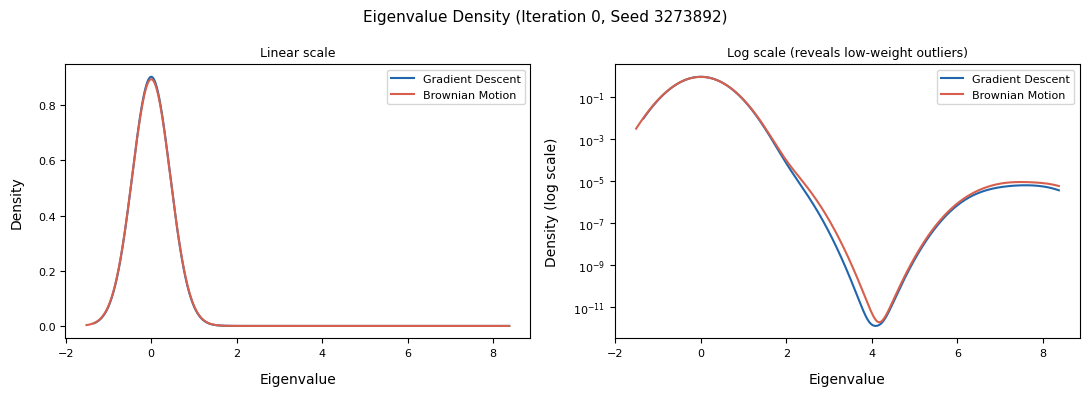

In [16]:
# "iteration" here means number of target updates, matching the paper's Figure 2 labels
# ("Initialization" vs "After 5 target updates"). Colors match the paper: gradient
# descent vs Brownian motion overlaid on the same axes with a legend.
get_esd_plot(
    [
        (eig_gd, weight_gd, "Gradient Descent", "#2166ac"),
        (eig_bm, weight_bm, "Brownian Motion", "#d6604d"),
    ],
    0, seed, out_dir=str(FIGURES_DIR / "esd"),
)

## Sanity Check the Shared Components

Before running the long loop, instantiate the shared MLP and true-label MDP, then step the environment once.

## Run the Experiment

The run couples two trajectories from the same initialization: one follows SGD on the Q-learning objective, and the other receives Brownian parameter perturbations with the same update norm.

In [17]:
optimizer = torch.optim.SGD(gd_model.parameters(), lr=lr)

In [18]:
def q_learning_loss(
    model: QNetwork,
    target_model: QNetwork,
    batch: Tuple[torch.Tensor, ...],
    gamma: float,
) -> torch.Tensor:
    states, actions, rewards, next_states = batch
    states = states.to(device)
    actions = actions.to(device)
    rewards = rewards.to(device)
    next_states = next_states.to(device)

    q_sa = model(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_q = target_model(next_states).max(dim=1).values
        td_target = rewards + gamma * next_q

    return F.mse_loss(q_sa, td_target)

In [19]:
def sgd_step_and_update_norm(
    model: QNetwork,
    target_model: QNetwork,
    optimizer: torch.optim.Optimizer,
    batch: Tuple[torch.Tensor, ...],
    gamma: float,
    lr: float,
) -> Tuple[float, float]:
    model.train()
    loss = q_learning_loss(model, target_model, batch, gamma)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    update_norm_sq = torch.zeros((), device=device)
    for p in model.parameters():
        if p.grad is not None:
            update_norm_sq += (lr * p.grad).pow(2).sum()

    optimizer.step()
    return float(loss.detach().cpu().item()), float(update_norm_sq.sqrt().cpu().item())

In [20]:
@torch.no_grad()
def evaluate_policy(
    model: QNetwork,
    env: EasyMDP,
    num_samples: int = 1024,
) -> float:
    model.eval()
    correct = 0

    for _ in range(num_samples):
        state = random.randrange(10)
        obs = env.sample_observation(state)
        pred = model(obs.unsqueeze(0).to(device)).argmax(dim=1).item()
        correct += int(pred == state)

    return correct / float(num_samples)

In [21]:
# Fixed probe inputs for the gradient-covariance snapshots below, sampled once from
# the (already-prefilled) replay buffer so both snapshots probe the same inputs.
cov_probe_inputs = replay.sample(cov_batch_size)[0]
cov_snapshots = {}  # (label, step) -> covariance matrix, filled in during the loop below

In [22]:
for step in tqdm(range(1, train_steps + 1)):

    collect_transition(env, gd_model, replay, epsilon=epsilon)

    batch = replay.sample(batch_size)
    loss, update_norm = sgd_step_and_update_norm(
        gd_model,
        target_model,
        optimizer,
        batch,
        gamma,
        lr,
    )
    brownian_update(bm_model, update_norm)

    if step in cov_snapshot_steps:
        # paper: gradient covariance snapshots at raw optimizer steps 1 and 20
        # (not target updates -- see the markdown cell above the plot below)
        for label, model in (("Gradient Descent", gd_model), ("Brownian Motion", bm_model)):
            probe_targets, _ = make_probe_targets(model, cov_probe_inputs)
            cov_snapshots[(label, step)] = compute_gradient_covariance(
                model, probe_criterion, cov_probe_inputs, probe_targets,
            )

    if step % target_update_period == 0:
        # save a snapshot of the current model parameters to the checkpoint directory
        torch.save(gd_model.state_dict(), CHECKPOINTS_DIR / f"hessian_step_{step}.pt")
        target_model.load_state_dict(gd_model.state_dict())
        target_update = step // target_update_period
        accuracy = evaluate_policy(gd_model, env, num_samples=1024)
        log_row = {
            "step": float(step),
            "target_update": float(target_update),
            "loss": float(loss),
            "update_norm": float(update_norm),
            "accuracy": float(accuracy),
        }
        print(
            "target update "
            f"{int(log_row['target_update'])}: "
            f"step={step}, loss={loss:.4f}, "
            f"update_norm={update_norm:.5f}, accuracy={accuracy:.3f}"
        )

  0%|          | 0/25000 [00:00<?, ?it/s]

  0%|          | 1/25000 [00:02<18:12:05,  2.62s/it]

  0%|          | 11/25000 [00:02<1:15:34,  5.51it/s]

  0%|          | 19/25000 [00:02<39:18, 10.59it/s]  

  0%|          | 26/25000 [00:04<1:12:03,  5.78it/s]

...

100%|█████████▉| 24981/25000 [04:06<00:00, 68.15it/s]

100%|█████████▉| 24990/25000 [04:06<00:00, 72.85it/s]

100%|█████████▉| 24999/25000 [04:06<00:00, 77.08it/s]

100%|██████████| 25000/25000 [04:06<00:00, 101.45it/s]

target update 5: step=25000, loss=0.1985, update_norm=0.00023, accuracy=0.439


## Reading the ESD Plots

`get_esd_plot` overlays both trajectories on the same axes with a legend, matching the paper: **Gradient Descent** vs **Brownian Motion**, each evaluated on its own random-target probe loss. It renders two panels. The **left (linear)** panel matches how Lyle et al. present Figure 2. The **right (log-scale)** panel is Ghorbani et al.'s own convention, included here because it matters for this specific reproduction: the outlier eigenvalue that develops after training carries a tiny fraction of the total SLQ weight (well under 0.1% in practice for this toy MLP/MDP), so it is mathematically invisible as a bump on a linear axis no matter how the smoothing kernel is tuned — it only shows up once density is put on a log scale. The paper doesn't state the exact architecture used for this experiment (Appendix A.1 gives optimizer/batch/target-period for Figure 2 but not width/depth), and a width sweep from 64 to 2048 didn't change this qualitative picture, so this looks like a genuine property of this reproduction's scale rather than a bug or a tunable hyperparameter.

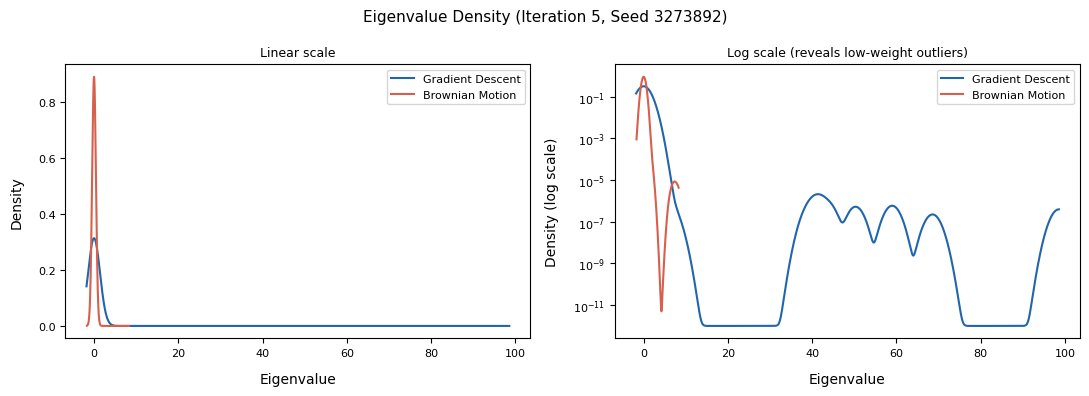

In [23]:
probe_batch = replay.sample(512)

probe_targets_gd, _ = make_probe_targets(gd_model, probe_batch[0])
hessian_gd = Hessian(
    model=gd_model,
    data=(probe_batch[0], probe_targets_gd),
    criterion=probe_criterion,
    cuda=False,
)
eig_gd, weight_gd = hessian_gd.density(iter=100, n_v=10)

probe_targets_bm, _ = make_probe_targets(bm_model, probe_batch[0])
hessian_bm = Hessian(
    model=bm_model,
    data=(probe_batch[0], probe_targets_bm),
    criterion=probe_criterion,
    cuda=False,
)
eig_bm, weight_bm = hessian_bm.density(iter=100, n_v=10)

get_esd_plot(
    [
        (eig_gd, weight_gd, "Gradient Descent", "#2166ac"),
        (eig_bm, weight_bm, "Brownian Motion", "#d6604d"),
    ],
    num_target_updates, seed, out_dir=str(FIGURES_DIR / "esd"),
)

In [24]:
num_clusters = 10  # paper: kmeans k=10, "to match the number of latent states in the environment"

cov_gd_1 = sort_by_kmeans(cov_snapshots[("Gradient Descent", 1)], num_clusters=num_clusters)
cov_bm_1 = sort_by_kmeans(cov_snapshots[("Brownian Motion", 1)], num_clusters=num_clusters)
cov_gd_20 = sort_by_kmeans(cov_snapshots[("Gradient Descent", 20)], num_clusters=num_clusters)
cov_bm_20 = sort_by_kmeans(cov_snapshots[("Brownian Motion", 20)], num_clusters=num_clusters)

## Gradient Covariance at Early Training Iterations

The paper's gradient-covariance panels use a different, much finer timescale than the ESD panels above: **"1 Iteration"** and **"20 Iterations"**, rather than target updates. These mean the 1st and 20th raw optimizer step of training (captured inside the training loop above via `cov_snapshot_steps`), not the 5000-step target-update cadence -- the paper never reconciles the two units explicitly, but this reading matches how an earlier version of this reproduction handled it (snapshotting at local steps 1 and 20 of the very first target-update block). This panel shows how quickly gradient-interference structure emerges, independent of the longer-horizon curvature story above.

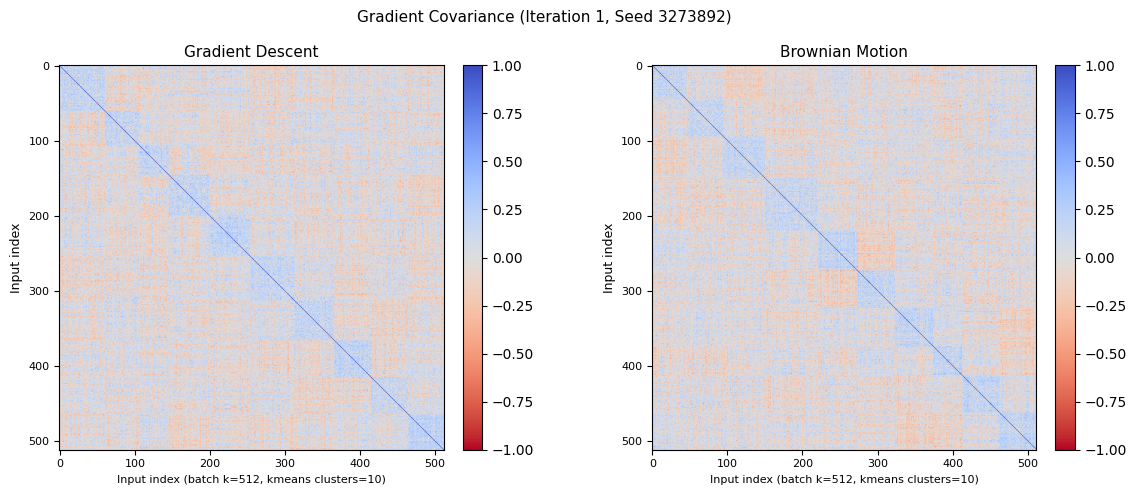

In [25]:
# iteration 1: gradient covariance right after the very first optimizer step
plot_gradient_covariance(
    [
        (cov_gd_1, "Gradient Descent"),
        (cov_bm_1, "Brownian Motion"),
    ],
    1, seed,
    batch_size=cov_batch_size, num_clusters=num_clusters,
    out_dir=str(FIGURES_DIR / "gradient_covariance"),
)

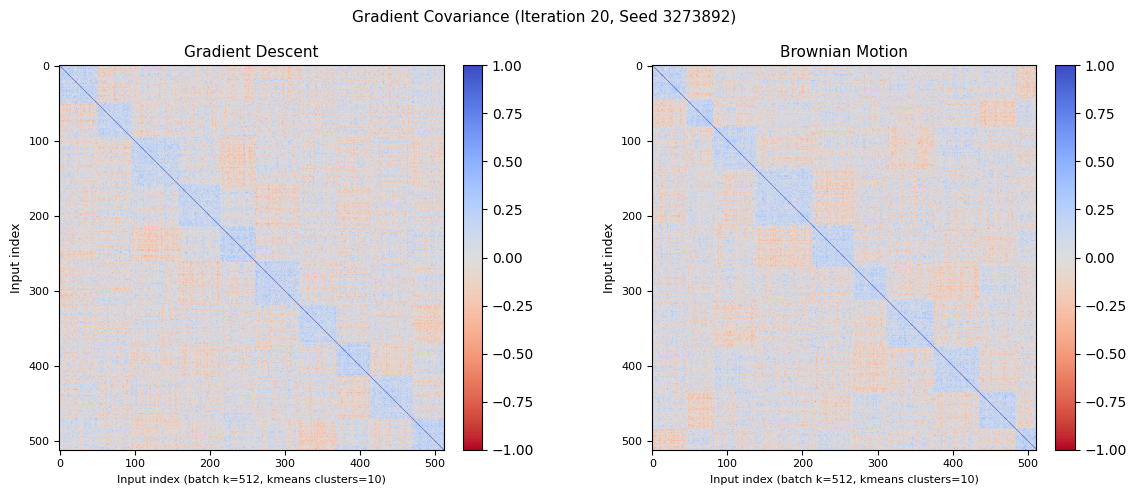

In [26]:
# iteration 20: gradient covariance after 20 optimizer steps
plot_gradient_covariance(
    [
        (cov_gd_20, "Gradient Descent"),
        (cov_bm_20, "Brownian Motion"),
    ],
    20, seed,
    batch_size=cov_batch_size, num_clusters=num_clusters,
    out_dir=str(FIGURES_DIR / "gradient_covariance"),
)